# Classification Improvements

This notebook tests two techniques to address the class imbalance and overfitting observed in `04_SL_classification.ipynb`:

1. **Dummy Classifier** — baseline to evaluate how much better our real models actually are
2. **Class Weights** — penalise errors on minority classes (noise 0, 1, 4) to improve recall

## Setup

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

from mlxtend.plotting import plot_confusion_matrix

sns.set(color_codes=True, rc={'figure.figsize': (10, 8)})

In [32]:
data = pd.read_csv("data/bcn_noise_class_ml_dataset.csv")
data_clean = data.dropna(how='any').reset_index(drop=True)

X = data_clean.drop(columns=['road_id', 'noise_day', 'noise_evening', 'noise_night'])
y = np.asarray(data_clean['noise_day'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class distribution:\n{pd.Series(y_train).value_counts().sort_index()}")

Train: (10283, 18)  |  Test: (2571, 18)
Class distribution:
0     111
1     463
2    2977
3    5509
4    1223
Name: count, dtype: int64


## 1. Dummy Classifier (Baseline)

A `DummyClassifier` ignores all features and predicts using a naive rule — here, always the most frequent class.

**Why it matters:** if our real models only marginally beat this, the model is not actually learning anything useful.
Any real model should score clearly above this baseline.

In [33]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

print("Dummy Classifier — most_frequent strategy")
print(f"  Train accuracy: {dummy.score(X_train, y_train):.4f}")
print(f"  Test accuracy:  {dummy.score(X_test, y_test):.4f}")
print()
print(classification_report(y_test, dummy.predict(X_test)))

Dummy Classifier — most_frequent strategy
  Train accuracy: 0.5357
  Test accuracy:  0.5457

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        21
           1       0.00      0.00      0.00       119
           2       0.00      0.00      0.00       728
           3       0.55      1.00      0.71      1403
           4       0.00      0.00      0.00       300

    accuracy                           0.55      2571
   macro avg       0.11      0.20      0.14      2571
weighted avg       0.30      0.55      0.39      2571



c:\Users\ecori\miniconda3\envs\data-encoding\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecori\miniconda3\envs\data-encoding\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ecori\miniconda3\envs\data-encoding\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

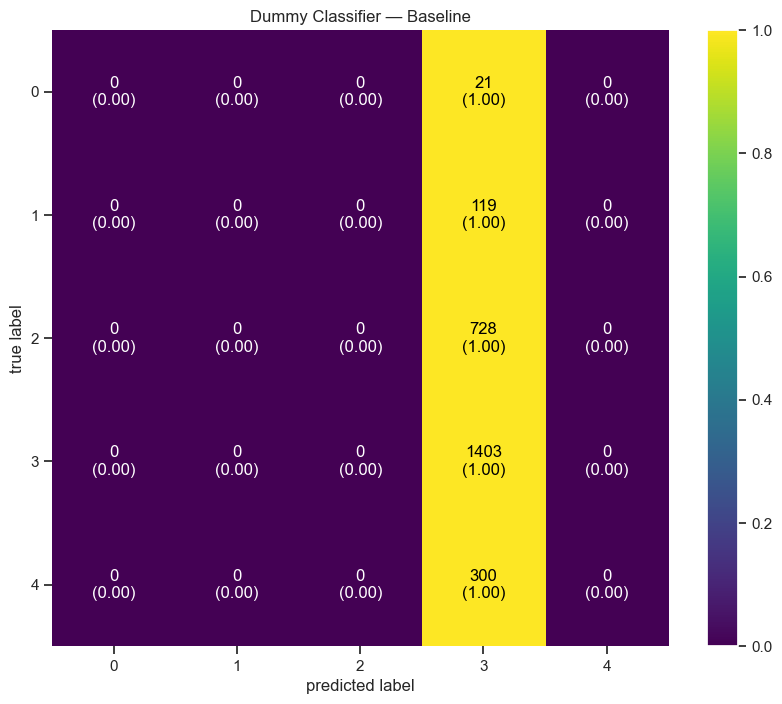

In [34]:
fig, ax = plot_confusion_matrix(
    conf_mat=confusion_matrix(y_test, dummy.predict(X_test)),
    colorbar=True,
    show_absolute=True,
    show_normed=True,
    hide_spines=True,
    cmap='viridis'
)
ax.set_title("Dummy Classifier — Baseline")
for text in ax.texts:
    text.set_color('black' if text.get_color() == 'white' else 'white')
plt.show()

## 2. Class Weights

The dataset is imbalanced — class 2 dominates. Without weighting, models optimise for the majority class and ignore rare classes (0, 1, 4).

`class_weight='balanced'` automatically scales penalties inversely proportional to class frequency:
$$w_c = \frac{n\_samples}{n\_classes \times n\_samples\_of\_class\_c}$$

**Expected effect:** lower overall accuracy, but better recall on minority classes — which is more useful for a noise prediction task.

### 2a. Logistic Regression

In [35]:
model_lr_w = LogisticRegression(max_iter=2000, class_weight='balanced')

scores_lr_w = cross_val_score(model_lr_w, X_train, y_train, cv=5)
model_lr_w.fit(X_train, y_train)

print("Logistic Regression (balanced)")
print(f"  CV scores:      {scores_lr_w.round(4)}  mean={scores_lr_w.mean():.4f}")
print(f"  Train accuracy: {model_lr_w.score(X_train, y_train):.4f}")
print(f"  Test accuracy:  {model_lr_w.score(X_test, y_test):.4f}")
print()
print(classification_report(y_test, model_lr_w.predict(X_test)))

Logistic Regression (balanced)
  CV scores:      [0.4769 0.4701 0.4531 0.4762 0.4543]  mean=0.4661
  Train accuracy: 0.4706
  Test accuracy:  0.4749

              precision    recall  f1-score   support

           0       0.19      0.76      0.30        21
           1       0.23      0.55      0.32       119
           2       0.48      0.59      0.53       728
           3       0.73      0.35      0.47      1403
           4       0.35      0.73      0.47       300

    accuracy                           0.47      2571
   macro avg       0.39      0.60      0.42      2571
weighted avg       0.59      0.47      0.48      2571



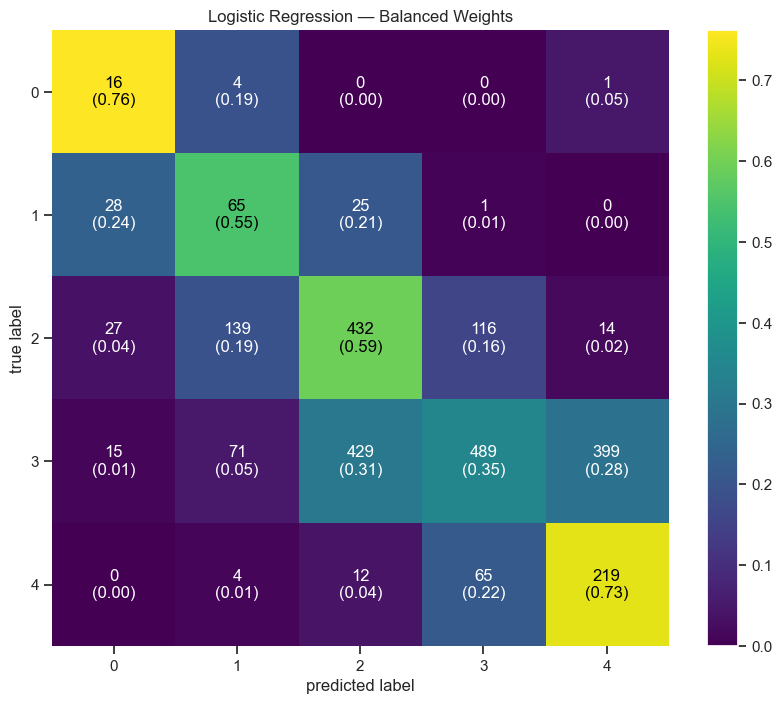

In [36]:
fig, ax = plot_confusion_matrix(
    conf_mat=confusion_matrix(y_test, model_lr_w.predict(X_test)),
    colorbar=True,
    show_absolute=True,
    show_normed=True,
    hide_spines=True,
    cmap='viridis'
)
ax.set_title("Logistic Regression — Balanced Weights")
for text in ax.texts:
    text.set_color('black' if text.get_color() == 'white' else 'white')
plt.show()

### 2b. Random Forest

In [37]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
sw = np.array([cw[c] for c in y_train])

model_rf_w = RandomForestClassifier(random_state=42)
model_rf_w.fit(X_train, y_train, sample_weight=sw)


print("Random Forest (balanced_subsample)")
print(f"  Train accuracy: {model_rf_w.score(X_train, y_train):.4f}")
print(f"  Test accuracy:  {model_rf_w.score(X_test, y_test):.4f}")
print()
print(classification_report(y_test, model_rf_w.predict(X_test)))

Random Forest (balanced_subsample)
  Train accuracy: 0.9984
  Test accuracy:  0.7518

              precision    recall  f1-score   support

           0       0.86      0.90      0.88        21
           1       0.83      0.64      0.72       119
           2       0.74      0.70      0.72       728
           3       0.75      0.87      0.81      1403
           4       0.72      0.38      0.50       300

    accuracy                           0.75      2571
   macro avg       0.78      0.70      0.73      2571
weighted avg       0.75      0.75      0.74      2571



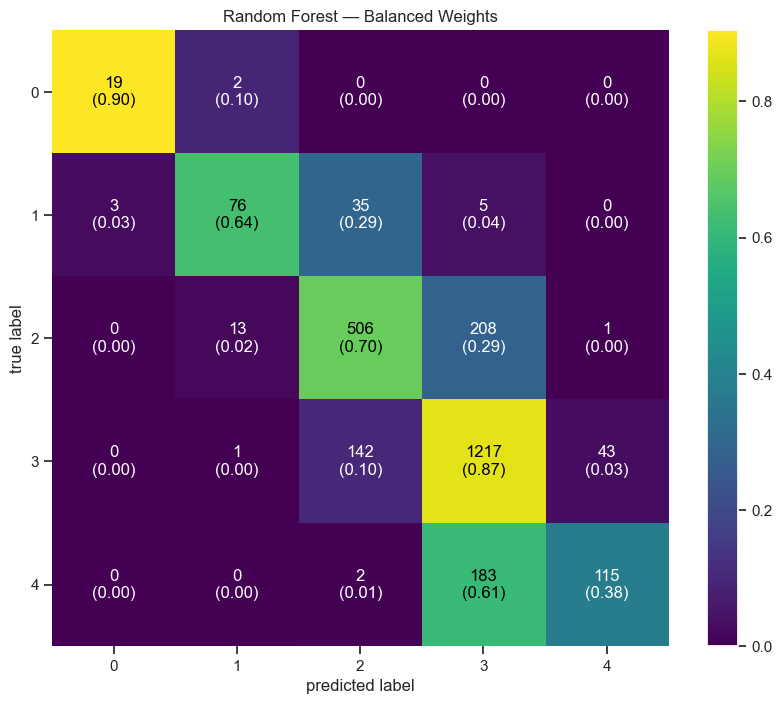

In [38]:
fig, ax = plot_confusion_matrix(
    conf_mat=confusion_matrix(y_test, model_rf_w.predict(X_test)),
    colorbar=True,
    show_absolute=True,
    show_normed=True,
    hide_spines=True,
    cmap='viridis'
)
ax.set_title("Random Forest — Balanced Weights")
for text in ax.texts:
    text.set_color('black' if text.get_color() == 'white' else 'white')
plt.show()

### 2c. XGBoost

XGBoost does not have a `class_weight` parameter for multiclass problems.
Instead, we compute per-sample weights using `compute_class_weight` and pass them to `fit()`.

In [39]:
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
sample_weights = np.array([class_weights[c] for c in y_train])

model_xgb_w = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
model_xgb_w.fit(X_train, y_train, sample_weight=sample_weights)

print("XGBoost (balanced sample weights)")
print(f"  Train accuracy: {model_xgb_w.score(X_train, y_train):.4f}")
print(f"  Test accuracy:  {model_xgb_w.score(X_test, y_test):.4f}")
print()
print(classification_report(y_test, model_xgb_w.predict(X_test)))

XGBoost (balanced sample weights)
  Train accuracy: 0.9263
  Test accuracy:  0.7188

              precision    recall  f1-score   support

           0       0.88      1.00      0.93        21
           1       0.70      0.73      0.72       119
           2       0.65      0.76      0.70       728
           3       0.81      0.70      0.75      1403
           4       0.56      0.69      0.62       300

    accuracy                           0.72      2571
   macro avg       0.72      0.78      0.74      2571
weighted avg       0.73      0.72      0.72      2571



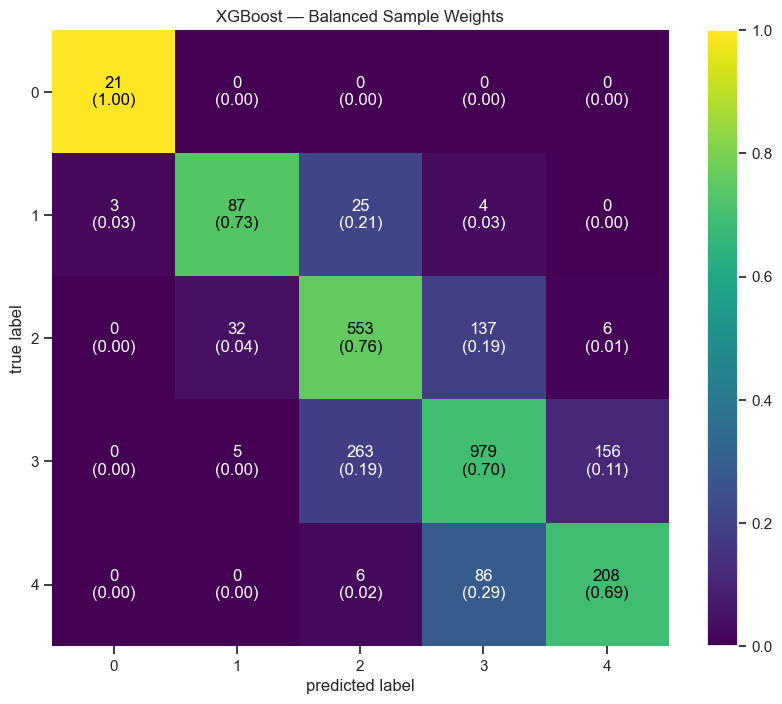

In [40]:
fig, ax = plot_confusion_matrix(
    conf_mat=confusion_matrix(y_test, model_xgb_w.predict(X_test)),
    colorbar=True,
    show_absolute=True,
    show_normed=True,
    hide_spines=True,
    cmap='viridis'
)
ax.set_title("XGBoost — Balanced Sample Weights")
for text in ax.texts:
    text.set_color('black' if text.get_color() == 'white' else 'white')
plt.show()

## Summary

| Model | Train acc | Test acc | Notes |
|---|---|---|---|
| Dummy (most_frequent) | — | ~% | Baseline — no learning |
| LR (balanced) | ~% | ~% | Compare with 61% unweighted |
| RF (balanced) | ~% | ~% | Compare with 99%/76% unweighted — does overfitting reduce? |
| XGBoost (balanced) | ~% | ~% | Compare with 96%/74% unweighted |

> Fill in the `~%` values after running. Focus on **per-class recall** in the classification reports — especially for classes 0, 1, and 4 which are minority classes.